<a href="https://colab.research.google.com/github/jhenningsen/Equity_Analysis/blob/main/Leverage_ETFs/Log_Mean_Reversion_Discrete.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TQQQ Trading Strategy Backtesting with Logarithmic Trend Mean Reversion

This notebook develops and backtests systematic trading strategies for TQQQ (ProShares UltraPro QQQ 3x Leveraged ETF) using a logarithmic trend mean reversion approach. The backtest period runs from TQQQ's inception date (February 11, 2010) to the present, utilizing adjusted prices from `yfinance`.

## Project Goals:
1.  **Develop Mean Reversion Strategies:** Implement and refine strategies that profit from TQQQ's tendency to revert to its long-term logarithmic trend.
2.  **Compare Performance:** Evaluate the strategies against a TQQQ Buy and Hold benchmark using key metrics like CAGR, Max Drawdown, Sharpe Ratio, and visual equity curves.

## Strategies:

### 1. Discrete Residual Mean Reversion Strategy (Initial Approach)
*   **Core Concept:** This strategy aims to profit from the tendency of TQQQ's price to revert to its long-term logarithmic trend. It identifies overbought and oversold conditions based on residuals from a linear regression of TQQQ's log price over time.
*   **Mechanics:** Uses Gaussian Mixture Models (GMM) to cluster the residuals into different regimes (e.g., most oversold, moderately oversold, moderately overbought, most overbought). Allocations to TQQQ are then dynamically adjusted based on these discrete residual regimes, with higher allocations when TQQQ is oversold and lower/zero allocations when overbought.

### 2. Continuous Residual Allocation Strategy (Refined Approach)
*   **Core Concept:** A refinement of the mean reversion approach, implementing a more *gradual* capital allocation based on TQQQ's residuals, updated on a **daily** basis. This provides a smoother and more responsive allocation change than the discrete regime strategy.
*   **Mechanics:**
    *   **Daily Residual Signal:** The strategy now uses the daily TQQQ residuals directly as the signal for allocation.
    *   **Sigmoid Allocation:** A sigmoid function is applied to the daily residual signal. This function is configured such that very negative residuals (oversold) result in high TQQQ allocation (approaching 100%), very positive residuals (overbought) result in low TQQQ allocation (approaching 0%), and residuals near zero result in moderate TQQQ allocation.
    *   **Minimum Allocation Floor:** The strategy incorporates the ability to set a minimum allocation floor, ensuring a certain percentage of capital is always invested in TQQQ, regardless of the sigmoid's output.
    *   **1-Day Lag:** A 1-day lag is applied to the calculated allocation to avoid look-ahead bias.

### 3. TQQQ Allocation Estimator Function (`get_tqqq_allocation_estimator`)
*   **Core Concept:** A self-contained Python function that provides a real-time estimation of the recommended TQQQ allocation based on the continuous sigmoid logic.
*   **Mechanics:**
    *   Downloads current TQQQ data from Yahoo Finance.
    *   Calculates an overall mean residual from the full historical dataset.
    *   Performs a specific linear regression (from 2011-01-01 to six months ago) to determine the current residual against this trend.
    *   Applies the continuous sigmoid allocation logic with `k_factor` and `Min Allocation` parameters.
    *   Outputs the recommended allocation and displays two charts: one for the full regression period and another for the last two years with the regression line overlaid.

### 4. Equity Curve Analysis for Estimator Strategy
*   **Core Concept:** Backtesting the `get_tqqq_allocation_estimator`'s allocation logic over the entire historical period to visualize its cumulative performance and quantify key risk/return metrics.
*   **Mechanics:**
    *   A helper function, `plot_allocation_estimator_equity_curve`, applies the estimator's continuous sigmoid logic (with specified `k_factor` and `Min Allocation`) to historical TQQQ data.
    *   Calculates daily returns based on the strategy's allocations.
    *   Plots the resulting equity curve against the TQQQ Buy & Hold benchmark.
    *   Provides detailed performance metrics (CAGR, Annualized Volatility, Sharpe Ratio, Max Drawdown) for both the strategy and the benchmark for direct comparison.

## Benchmark: TQQQ Buy and Hold
*   **Core Concept:** A pure, passive buy-and-hold baseline to evaluate strategy outperformance (Alpha) and risk-adjusted return profiles.
*   **Mechanics:** Fully vectorized execution. 100% of capital is deployed into TQQQ on day one, compounding daily based on TQQQ's fractional percent changes.
*   **Historical Performance:** Historically (2010–2026), this benchmark compounds at a ~40% to 44% CAGR, but suffers an extreme maximum drawdown of ~81.6% during the 2022 market regime shift.

In [38]:
# Import necessary libraries

import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.mixture import GaussianMixture
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display # Ensure display is available
from ipywidgets import interact, FloatSlider



In [39]:
# Clear all DataFrames from memory
import gc

# Get a list of all variables in the global namespace
all_vars = list(globals().keys())

# Identify and delete pandas DataFrames
for var_name in all_vars:
    if isinstance(globals()[var_name], pd.DataFrame):
        del globals()[var_name]
        print(f"Deleted DataFrame: {var_name}")

# Run garbage collector to free up memory
gc.collect()

print("All DataFrames cleared from memory.")

Deleted DataFrame: tqqq_data
Deleted DataFrame: regression_df
Deleted DataFrame: X
Deleted DataFrame: residual_summary
Deleted DataFrame: strategy_df
Deleted DataFrame: regression_df_continuous_strategy
Deleted DataFrame: strategy_df_continuous
Deleted DataFrame: temp_regression_df_continuous_strategy
Deleted DataFrame: temp_strategy_df_continuous
Deleted DataFrame: results_df
Deleted DataFrame: temp_regression_df_continuous_strategy_k
Deleted DataFrame: temp_strategy_df_continuous_k
Deleted DataFrame: results_k_factor_df
Deleted DataFrame: temp_regression_df_detailed
Deleted DataFrame: temp_strategy_df_detailed
Deleted DataFrame: results_detailed_df
Deleted DataFrame: results_df_full
Deleted DataFrame: top_performers
All DataFrames cleared from memory.


In [48]:
# Download TQQQ data
tickers = ["TQQQ"]
tqqq_data = yf.download(tickers, start="2010-02-11", end="2026-01-01", auto_adjust=True)['Close'].dropna()

# Convert to DataFrame if it's a Series (ensure tqqq_data is a DataFrame for subsequent operations)
if isinstance(tqqq_data, pd.Series):
    tqqq_data = tqqq_data.to_frame(name='TQQQ')

# Calculate TQQQ returns and create benchmark equity
tqqq_data['TQQQ_Return'] = tqqq_data['TQQQ'].pct_change()

# Create a copy for regression analysis and to serve as the consistent base for all strategies
regression_df = tqqq_data.copy()

# Calculate Standard_Benchmark_Equity once here to be used across all strategies
initial_portfolio_value_benchmark = 100000.0
# Use fillna(1) for the first return to correctly initialize cumprod for the benchmark
regression_df['Standard_Benchmark_Equity'] = (1 + regression_df['TQQQ_Return']).fillna(1).cumprod() * initial_portfolio_value_benchmark

print("TQQQ data and Benchmark Equity prepared.")

# Calculate TQQQ log price, trend line, and residuals
regression_df['TQQQ_Log_Price'] = np.log(regression_df['TQQQ'])
regression_df['Days_Since_Start'] = np.arange(len(regression_df))
X = regression_df[['Days_Since_Start']]
y = regression_df['TQQQ_Log_Price']
model = LinearRegression()
model.fit(X, y)
regression_df['TQQQ_Trend_Line'] = model.predict(X)
regression_df['TQQQ_Residuals'] = regression_df['TQQQ_Log_Price'] - regression_df['TQQQ_Trend_Line']

print("TQQQ Log Price, Trend Line, and Residuals calculated and added to regression_df for plotting.")

[*********************100%***********************]  1 of 1 completed

TQQQ data and Benchmark Equity prepared.
TQQQ Log Price, Trend Line, and Residuals calculated and added to regression_df for plotting.


Now, let's visualize the log price, the linear regression trend line, and the residuals. This will help us understand the deviations from the trend.

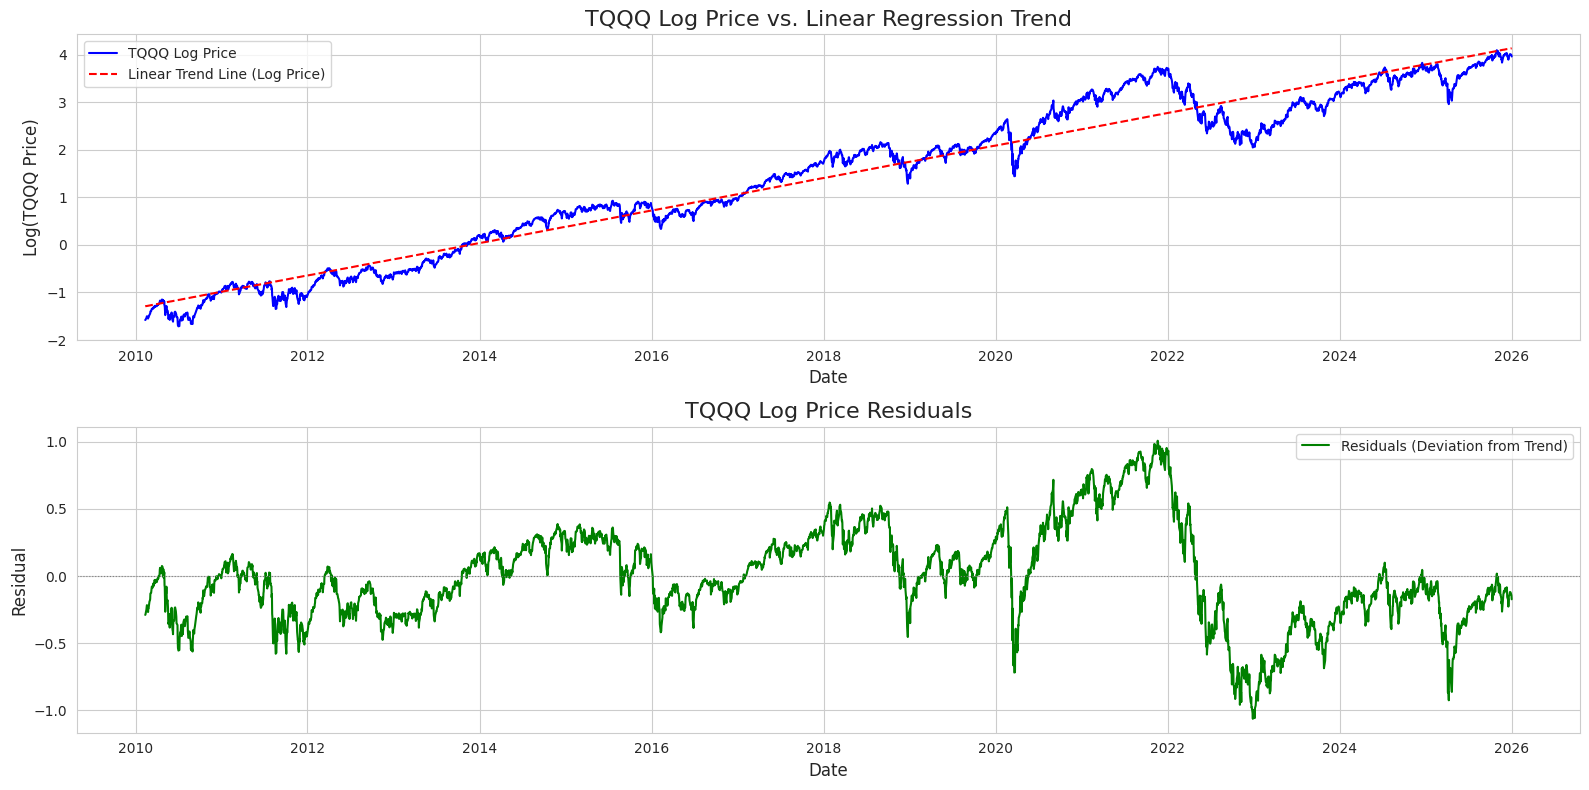

In [47]:
# Plot TQQQ log price, trend, and residuals
plt.figure(figsize=(16, 8))

# Plot Log Price and Trend Line
plt.subplot(2, 1, 1) # 2 rows, 1 column, first plot
plt.plot(regression_df.index, regression_df['TQQQ_Log_Price'], label='TQQQ Log Price', color='blue')
plt.plot(regression_df.index, regression_df['TQQQ_Trend_Line'], label='Linear Trend Line (Log Price)', color='red', linestyle='--')
plt.title('TQQQ Log Price vs. Linear Regression Trend', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Log(TQQQ Price)', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True)

# Plot Residuals
plt.subplot(2, 1, 2) # 2 rows, 1 column, second plot
plt.plot(regression_df.index, regression_df['TQQQ_Residuals'], label='Residuals (Deviation from Trend)', color='green')
plt.axhline(0, color='gray', linestyle=':', linewidth=0.8)
plt.title('TQQQ Log Price Residuals', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Residual', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True)

plt.tight_layout()
plt.show()

The residuals represent how far TQQQ's log price is from its calculated long-term linear trend. A mean reversion strategy would typically involve:

1.  **Going Long (Buying TQQQ):** When the residuals fall significantly below zero, indicating TQQQ is oversold relative to its trend.
2.  **Going Short (Selling TQQQ):** When the residuals rise significantly above zero, indicating TQQQ is overbought relative to its trend.

You would need to define thresholds (e.g., standard deviations of residuals) to trigger these buy/sell signals.

## Mean Reversion Strategy Implementation

In [58]:
def run_discrete_gmm_strategy(base_regression_df, n_components, initial_portfolio_value):
    """
    Runs a discrete GMM-based mean reversion strategy for a given number of components.

    Args:
        base_regression_df (pd.DataFrame): The DataFrame containing TQQQ data, log prices,
                                            trend lines, residuals, and benchmark equity.
        n_components (int): The number of Gaussian Mixture Model components (regimes).
        initial_portfolio_value (float): The starting portfolio value for the backtest.

    Returns:
        dict: A dictionary containing the strategy DataFrame, performance metrics, and residual summary.
    """
    regression_df = base_regression_df.copy() # Work on a copy to avoid modifying original

    # GMM for n_components
    X_residuals = regression_df['TQQQ_Residuals'].values.reshape(-1, 1)
    gmm_residuals = GaussianMixture(n_components=n_components, random_state=42, covariance_type='full')
    raw_labels_residuals = gmm_residuals.fit_predict(X_residuals)
    idx_residuals = np.argsort(gmm_residuals.means_.flatten())
    state_map_residuals = {old_label: new_label for new_label, old_label in enumerate(idx_residuals)}
    regression_df['Residual_Regime'] = [state_map_residuals[label] for label in raw_labels_residuals]

    # Generate and display the summary of discovered residual regimes
    residual_summary = regression_df.groupby('Residual_Regime')['TQQQ_Residuals'].agg(['min', 'max', 'mean', 'count'])

    # Dynamically define allocation_map based on n_components
    # Allocations range from 1.0 (most oversold) to 0.0 (most overbought)
    allocation_map = {i: 1.0 - (i / (n_components - 1)) if n_components > 1 else 1.0 for i in range(n_components)}
    regression_df['Target_Allocation'] = regression_df['Residual_Regime'].map(allocation_map)

    # Backtest and create strategy_df
    strategy_df = regression_df[['TQQQ', 'TQQQ_Return', 'Target_Allocation', 'Standard_Benchmark_Equity']].copy()
    strategy_df['TQQQ_Daily_Return'] = strategy_df['TQQQ_Return']
    strategy_df = strategy_df.dropna()
    strategy_df['Allocated_Weight'] = strategy_df['Target_Allocation'].shift(1)
    strategy_df = strategy_df.dropna()
    strategy_df['Strategy_Daily_Return'] = strategy_df['Allocated_Weight'] * strategy_df['TQQQ_Daily_Return']

    strategy_df['Strategy_Equity'] = (1 + strategy_df['Strategy_Daily_Return']).cumprod() * initial_portfolio_value
    strategy_df['Benchmark_Equity'] = strategy_df['Standard_Benchmark_Equity'].reindex(strategy_df.index)

    # Metrics calculation function
    def calculate_metrics(return_series, equity_series, initial_value):
        if len(equity_series) == 0 or initial_value == 0:
            return 0.0, 0.0, 0.0, 0.0

        total_return = (equity_series.iloc[-1] / initial_value - 1)
        # Ensure we have enough data points for annualization
        if len(equity_series) < 252:
            years = len(equity_series) / 252.0 if len(equity_series) > 0 else 1.0
        else:
            years = (equity_series.index[-1] - equity_series.index[0]).days / 365.25

        cagr = ((equity_series.iloc[-1] / initial_value) ** (1 / years) - 1) * 100 if years > 0 else 0.0
        ann_vol = return_series.std() * np.sqrt(252) * 100
        sharpe = cagr / ann_vol if ann_vol != 0 else 0.0

        rolling_max = equity_series.cummax()
        drawdowns = (equity_series - rolling_max) / rolling_max
        max_dd = drawdowns.min() * 100
        return cagr, ann_vol, sharpe, max_dd

    strat_cagr, strat_vol, strat_sharpe, strat_mdd = calculate_metrics(
        strategy_df['Strategy_Daily_Return'], strategy_df['Strategy_Equity'], initial_portfolio_value)
    bench_cagr, bench_vol, bench_sharpe, bench_mdd = calculate_metrics(
        strategy_df['TQQQ_Daily_Return'], strategy_df['Benchmark_Equity'], initial_portfolio_value)

    final_strat_equity = strategy_df['Strategy_Equity'].iloc[-1]
    final_bench_equity = strategy_df['Benchmark_Equity'].iloc[-1]

    val_strat_str = f"${final_strat_equity:,.2f}"
    val_bench_str = f"${final_bench_equity:,.2f}"
    cagr_strat_str = f"{strat_cagr:.2f}%"
    cagr_bench_str = f"{bench_cagr:.2f}%"
    mdd_strat_str = f"{strat_mdd:.2f}%"
    mdd_bench_str = f"{bench_mdd:.2f}%"

    results = {
        'strategy_df': strategy_df,
        'residual_summary': residual_summary,
        'strat_cagr': strat_cagr, 'strat_vol': strat_vol, 'strat_sharpe': strat_sharpe, 'strat_mdd': strat_mdd,
        'bench_cagr': bench_cagr, 'bench_vol': bench_vol, 'bench_sharpe': bench_sharpe, 'bench_mdd': bench_mdd,
        'val_strat_str': val_strat_str, 'val_bench_str': val_bench_str,
        'cagr_strat_str': cagr_strat_str, 'cagr_bench_str': cagr_bench_str,
        'mdd_strat_str': mdd_strat_str, 'mdd_bench_str': mdd_bench_str
    }
    return results

### Mean Reversion Strategy based on Logarithmic Trend - 4 Residuals

### Backtesting the 4 Discrete Residual Mean Reversion Strategy

In [59]:
# Run the discrete GMM strategy for 4 components
initial_portfolio_value = 100000.0
gmm_4_component_results = run_discrete_gmm_strategy(regression_df, n_components=4, initial_portfolio_value=initial_portfolio_value)

# Extract results for printing
strategy_df = gmm_4_component_results['strategy_df'] # Assign to strategy_df to maintain consistency with plot cell
residual_summary_4_comp = gmm_4_component_results['residual_summary']
val_strat_str = gmm_4_component_results['val_strat_str']
val_bench_str = gmm_4_component_results['val_bench_str']
cagr_strat_str = gmm_4_component_results['cagr_strat_str']
cagr_bench_str = gmm_4_component_results['cagr_bench_str']
strat_vol = gmm_4_component_results['strat_vol']
bench_vol = gmm_4_component_results['bench_vol']
strat_sharpe = gmm_4_component_results['strat_sharpe']
bench_sharpe = gmm_4_component_results['bench_sharpe']
mdd_strat_str = gmm_4_component_results['mdd_strat_str']
mdd_bench_str = gmm_4_component_results['mdd_bench_str']

print("\n--- DISCOVERED RESIDUAL REGIMES (4 Components) ---")
display(residual_summary_4_comp)
print(f"\n{'Metric':<25}{'Residual Mean Reversion':<25}{'TQQQ Buy & Hold':<20}")
print("-" * 70)
print(f"{'Ending Portfolio Value':<25}{val_strat_str:<25}{val_bench_str:<20}")
print(f"{'CAGR':<25}{cagr_strat_str:<25}{cagr_bench_str:<20}")
print(f"{'Annualized Vol':<25}{f'{strat_vol:.2f}%':<25}{f'{bench_vol:.2f}%':<20}")
print(f"{'Sharpe Ratio':<25}{f'{strat_sharpe:.2f}':<25}{f'{bench_sharpe:.2f}':<20}")
print(f"{'Max Drawdown':<25}{mdd_strat_str:<25}{mdd_bench_str:<20}")
print("-" * 70)


--- DISCOVERED RESIDUAL REGIMES (4 Components) ---


,min,max,mean,count
Residual_Regime,,,,
0,-1.063691,-0.453206,-0.655360,316
1,-0.451638,0.024853,-0.179508,1941
2,0.025514,0.455914,0.213830,1346
3,0.456364,1.008557,0.679451,394



Metric                   Residual Mean Reversion  TQQQ Buy & Hold     
----------------------------------------------------------------------
Ending Portfolio Value   $23,296,411.44           $25,543,135.53      
CAGR                     40.98%                   41.80%              
Annualized Vol           39.95%                   61.11%              
Sharpe Ratio             1.03                     0.68                
Max Drawdown             -51.18%                  -81.66%             
----------------------------------------------------------------------


### 4 Discrete Residual Mean Reversion Strategy Equity Curve

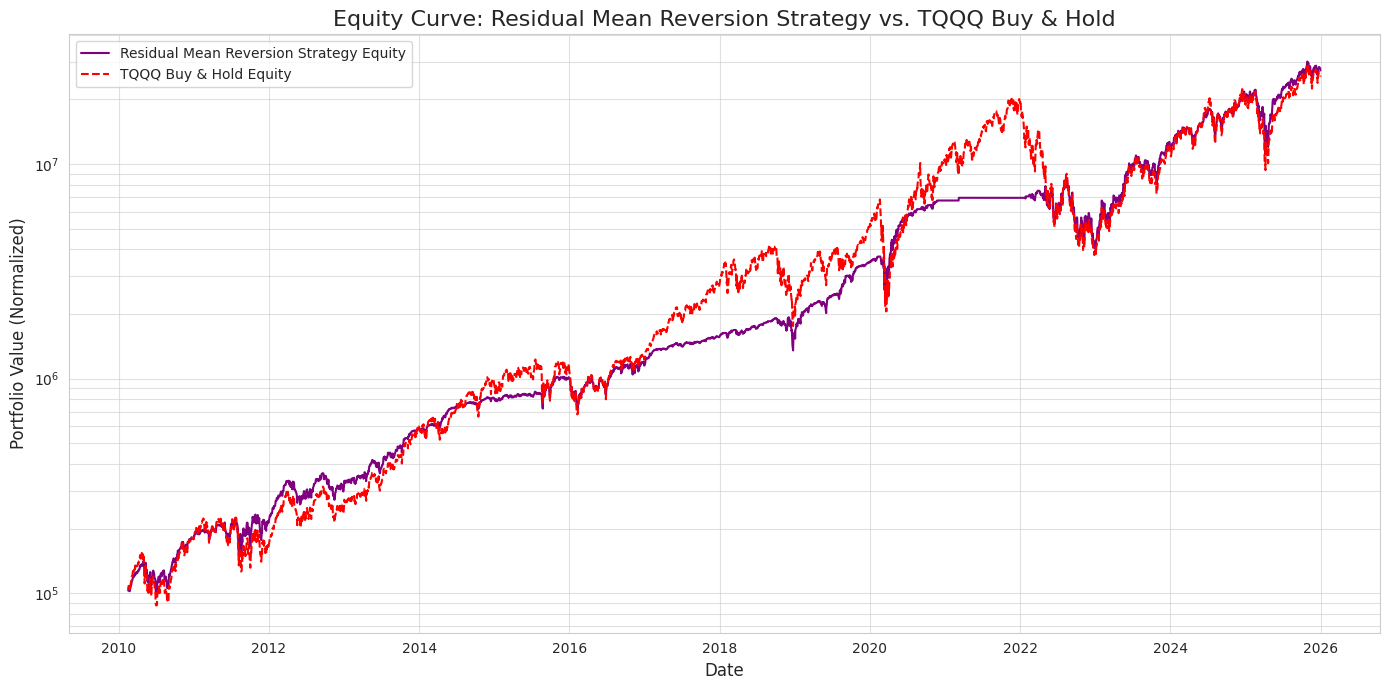

In [44]:
# Plot equity curve for Residual Mean Reversion Strategy
sns.set_style('whitegrid')
plt.figure(figsize=(14, 7))

plt.plot(strategy_df.index, strategy_df['Strategy_Equity'], label='Residual Mean Reversion Strategy Equity', color='purple')
plt.plot(strategy_df.index, strategy_df['Benchmark_Equity'], label='TQQQ Buy & Hold Equity', color='red', linestyle='--')

plt.title('Equity Curve: Residual Mean Reversion Strategy vs. TQQQ Buy & Hold', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Portfolio Value (Normalized)', fontsize=12)
plt.legend(fontsize=10)
plt.yscale('log') # Use log scale for better visualization of exponential growth
plt.grid(True, which="both", ls="-", alpha=0.6)
plt.tight_layout()
plt.show()

## Mean Reversion Strategy based on Logarithmic Trend - 5 Residuals

In [60]:
# Run the discrete GMM strategy for 5 components
initial_portfolio_value = 100000.0
gmm_5_component_results = run_discrete_gmm_strategy(regression_df, n_components=5, initial_portfolio_value=initial_portfolio_value)

# Extract results for printing
strategy_df_5_comp = gmm_5_component_results['strategy_df'] # Use a different name to avoid conflict with 4-comp strategy_df
residual_summary_5_comp = gmm_5_component_results['residual_summary']
val_strat_str_5_comp = gmm_5_component_results['val_strat_str']
val_bench_str_5_comp = gmm_5_component_results['val_bench_str']
cagr_strat_str_5_comp = gmm_5_component_results['cagr_strat_str']
cagr_bench_str_5_comp = gmm_5_component_results['cagr_bench_str']
strat_vol_5_comp = gmm_5_component_results['strat_vol']
bench_vol_5_comp = gmm_5_component_results['bench_vol']
strat_sharpe_5_comp = gmm_5_component_results['strat_sharpe']
bench_sharpe_5_comp = gmm_5_component_results['bench_sharpe']
mdd_strat_str_5_comp = gmm_5_component_results['mdd_strat_str']
mdd_bench_str_5_comp = gmm_5_component_results['mdd_bench_str']

print("\n--- DISCOVERED RESIDUAL REGIMES (5 Components) ---")
display(residual_summary_5_comp)
print(f"\n--- 5-COMPONENT GMM STRATEGY PERFORMANCE ---")
print(f"\n{'Metric':<25}{'Residual Mean Reversion':<25}{'TQQQ Buy & Hold':<20}")
print("-" * 70)
print(f"{'Ending Portfolio Value':<25}{val_strat_str_5_comp:<25}{val_bench_str_5_comp:<20}")
print(f"{'CAGR':<25}{cagr_strat_str_5_comp:<25}{cagr_bench_str_5_comp:<20}")
print(f"{'Annualized Vol':<25}{f'{strat_vol_5_comp:.2f}%':<25}{f'{bench_vol_5_comp:.2f}%':<20}")
print(f"{'Sharpe Ratio':<25}{f'{strat_sharpe_5_comp:.2f}':<25}{f'{bench_sharpe_5_comp:.2f}':<20}")
print(f"{'Max Drawdown':<25}{mdd_strat_str_5_comp:<25}{mdd_bench_str_5_comp:<20}")
print("-" * 70)


--- DISCOVERED RESIDUAL REGIMES (5 Components) ---


,min,max,mean,count
Residual_Regime,,,,
0,-1.063691,-0.505831,-0.695550,258
1,-0.503601,-0.194630,-0.314544,885
2,-0.194052,0.095381,-0.057991,1395
3,0.096798,0.513264,0.270624,1146
4,0.514701,1.008557,0.730306,313



--- 5-COMPONENT GMM STRATEGY PERFORMANCE ---

Metric                   Residual Mean Reversion  TQQQ Buy & Hold     
----------------------------------------------------------------------
Ending Portfolio Value   $18,757,569.64           $25,543,135.53      
CAGR                     39.07%                   41.80%              
Annualized Vol           38.33%                   61.11%              
Sharpe Ratio             1.02                     0.68                
Max Drawdown             -50.89%                  -81.66%             
----------------------------------------------------------------------
